# Tulu Pipeline Results Review

This notebook ingests artifacts from `scripts/run_tulu_pipeline.sh` and summarizes training completion, evaluation coverage, and benchmark comparisons for:

- Centralized Tulu training
- Naive FedAvg on Tulu
- Subspace Bank (bank-per-client)


## 1. Setup and discovery


In [1]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
plt.style.use('ggplot')


In [2]:
FS_ROOT = Path.cwd()
if (FS_ROOT / 'FederatedScope').is_dir():
    FS_ROOT = FS_ROOT / 'FederatedScope'

WORSTCASE_ROOT = FS_ROOT / 'tulu_worstcase_results'
WORSTCASE_RUN_ID = os.environ.get('TULU_WORSTCASE_RUN', '').strip()
if not WORSTCASE_RUN_ID:
    if WORSTCASE_ROOT.exists():
        run_dirs = [p for p in WORSTCASE_ROOT.iterdir() if p.is_dir()]
    else:
        run_dirs = []
    WORSTCASE_RUN_ID = max(run_dirs, key=lambda p: p.stat().st_mtime).name if run_dirs else ''

RESULTS_DIR = WORSTCASE_ROOT / WORSTCASE_RUN_ID if WORSTCASE_RUN_ID else WORSTCASE_ROOT

EXPERIMENTS = {
    'centralized': {
        'label': 'Centralized',
        'ckpt': RESULTS_DIR / 'centralized' / 'train' / 'ckpt.ckpt',
    },
    'fedavg': {
        'label': 'FedAvg',
        'ckpt': RESULTS_DIR / 'fedavg' / 'train' / 'ckpt.ckpt',
    },
    'bank_perclient': {
        'label': 'Subspace Bank',
        'ckpt': RESULTS_DIR / 'bank_perclient' / 'train' / 'ckpt.ckpt',
    },
}

BENCHMARKS = ['mmlu', 'gsm8k', 'humaneval']


In [3]:
from datetime import datetime


def _format_mtime(path):
    if path is None:
        return None
    try:
        ts = path.stat().st_mtime
    except FileNotFoundError:
        return None
    return datetime.fromtimestamp(ts).strftime('%Y-%m-%d %H:%M:%S')


def _find_eval_result_dir(base_dir):
    if not base_dir.exists():
        return None
    candidates = [path for path in base_dir.rglob('eval_result') if path.is_dir()]
    if not candidates:
        return None
    return max(candidates, key=lambda p: p.stat().st_mtime)


def _find_task_file(eval_dir, task):
    if task == 'gsm8k':
        pattern = 'accuracies_*__gsm8k.json'
    elif task == 'humaneval':
        pattern = 'accuracies_*__humaneval.json'
    else:
        pattern = 'accuracies_*.json'
    matches = sorted(eval_dir.glob(pattern))
    if task == 'mmlu':
        matches = [
            path for path in matches
            if '__gsm8k' not in path.name and '__humaneval' not in path.name
        ]
    if not matches:
        return None
    if len(matches) > 1:
        matches.sort(key=lambda p: p.stat().st_mtime)
    return matches[-1]


def load_eval_result(exp_key, benchmark):
    base_dir = RESULTS_DIR / 'global' / exp_key / benchmark
    eval_dir = _find_eval_result_dir(base_dir)
    if eval_dir is None:
        return None, None
    result_path = _find_task_file(eval_dir, benchmark)
    if result_path is None:
        return None, None
    with result_path.open('r', encoding='utf-8') as f:
        return json.load(f), result_path


def _list_run_dirs(base_dir):
    if not base_dir.exists():
        return []
    return [p for p in base_dir.iterdir() if p.is_dir()]


def _latest_run_dir(base_dir):
    run_dirs = _list_run_dirs(base_dir)
    if not run_dirs:
        return None
    return max(run_dirs, key=lambda p: p.stat().st_mtime)


def summarize_training():
    rows = []
    for exp_key, exp in EXPERIMENTS.items():
        ckpt = exp['ckpt']
        final_ckpt = ckpt.parent / 'final_ckpt.ckpt' if ckpt else None
        ckpt_path = final_ckpt if final_ckpt and final_ckpt.exists() else ckpt
        ckpt_exists = (ckpt_path.exists() if ckpt_path else True)
        rows.append({
            'experiment': exp_key,
            'label': exp['label'],
            'ckpt_exists': ckpt_exists,
            'ckpt_path': str(ckpt_path) if ckpt_path else 'n/a',
            'ckpt_mtime': _format_mtime(ckpt_path) if ckpt_path else None,
        })
    return pd.DataFrame(rows)


def summarize_eval_dirs():
    rows = []
    for exp_key in EXPERIMENTS:
        for bench in BENCHMARKS:
            base = RESULTS_DIR / 'global' / exp_key / bench
            run_dirs = _list_run_dirs(base)
            eval_dir = _find_eval_result_dir(base) if base.exists() else None
            rows.append({
                'experiment': exp_key,
                'benchmark': bench,
                'eval_runs': len(run_dirs),
                'latest_eval_dir': str(eval_dir) if eval_dir else None,
                'latest_eval_mtime': _format_mtime(eval_dir),
            })
    return pd.DataFrame(rows)


def _extract_metrics(payload, benchmark):
    if payload is None:
        return None, None, {}
    metrics = {
        'weighted_accuracy': payload.get('weighted_accuracy'),
        'strict_accuracy': payload.get('strict_accuracy'),
        'pass@1': payload.get('pass@1'),
        'pass@5': payload.get('pass@5'),
    }
    if benchmark == 'humaneval':
        metric = 'pass@1'
        value = metrics.get('pass@1')
        if value is None:
            metric = 'pass@5'
            value = metrics.get('pass@5')
    else:
        metric = 'weighted_accuracy'
        value = metrics.get('weighted_accuracy')
    return metric, value, metrics


def summarize_eval_results():
    rows = []
    for exp_key, exp in EXPERIMENTS.items():
        for bench in BENCHMARKS:
            payload, eval_path = load_eval_result(exp_key, bench)
            metric, value, metrics = _extract_metrics(payload, bench)
            rows.append({
                'experiment': exp_key,
                'benchmark': bench,
                'metric': metric,
                'primary_value': value,
                'weighted_accuracy': metrics.get('weighted_accuracy'),
                'strict_accuracy': metrics.get('strict_accuracy'),
                'pass@1': metrics.get('pass@1'),
                'pass@5': metrics.get('pass@5'),
                'eval_result_path': str(eval_path) if eval_path else None,
                'eval_result_mtime': _format_mtime(eval_path) if eval_path else None,
            })
    return pd.DataFrame(rows)


## 2. Completion status


In [4]:
training_df = summarize_training()
eval_dirs_df = summarize_eval_dirs()
eval_results_df = summarize_eval_results()

status_df = eval_dirs_df.merge(
    eval_results_df,
    on=['experiment', 'benchmark'],
    how='left',
)

status_df['eval_result_found'] = status_df['eval_result_path'].notna()

print(f"FS_ROOT: {FS_ROOT}")
print(f"WORSTCASE_RUN_ID: {WORSTCASE_RUN_ID or 'n/a'}")
print(f"RESULTS_DIR: {RESULTS_DIR}")

print("
Training checkpoints")
display(training_df)

print("
Evaluation runs + result artifacts")
display(status_df)

print("
Parsed evaluation metrics")
display(eval_results_df)


SyntaxError: EOL while scanning string literal (3423839362.py, line 17)

## 3. Benchmark comparisons


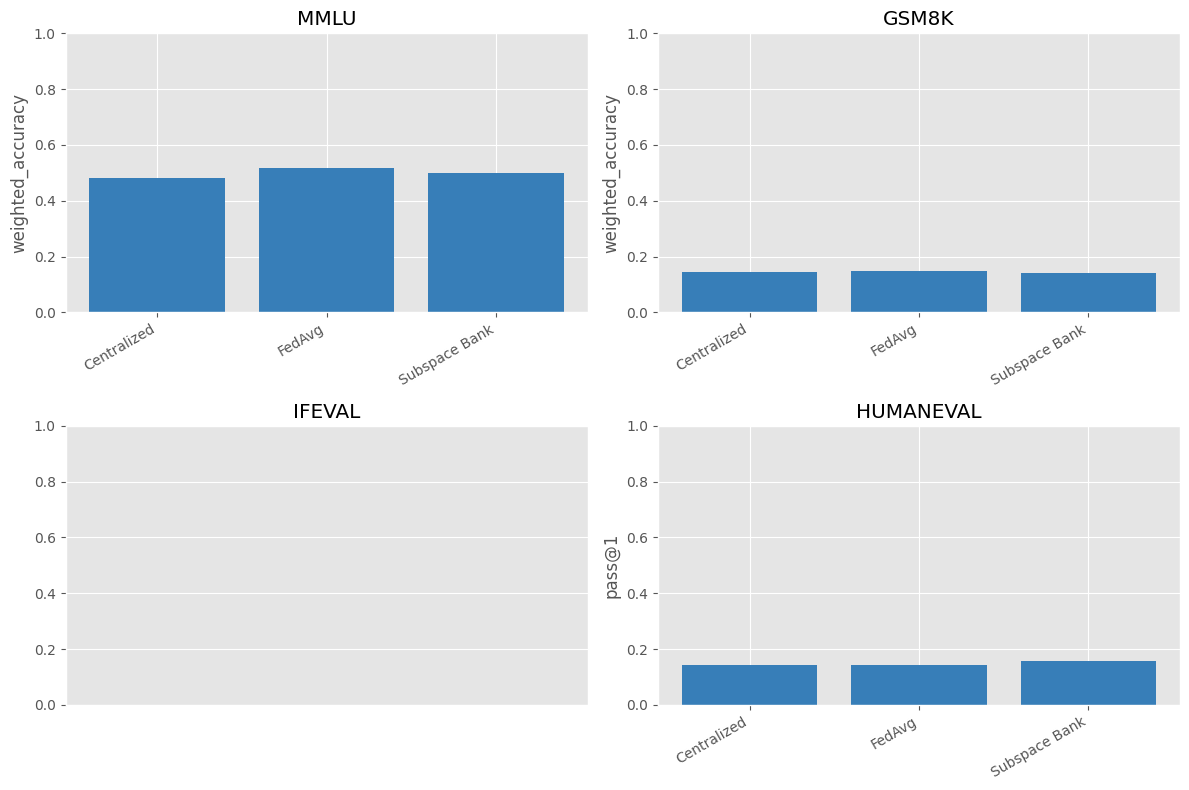

In [ ]:
plot_df = eval_results_df.copy()
plot_df['label'] = plot_df['experiment'].map(
    {k: v['label'] for k, v in EXPERIMENTS.items()}
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for idx, bench in enumerate(BENCHMARKS):
    ax = axes[idx]
    bench_df = plot_df[plot_df['benchmark'] == bench]
    bench_df = bench_df.sort_values('label')
    bench_df = bench_df[bench_df['primary_value'].notna()]
    x = np.arange(len(bench_df))
    ax.bar(x, bench_df['primary_value'], color='#377eb8')
    ax.set_title(bench.upper())
    metric_label = bench_df['metric'].iloc[0] if not bench_df.empty else ''
    ax.set_ylabel(metric_label)
    ax.set_xticks(x)
    ax.set_xticklabels(bench_df['label'], rotation=30, ha='right')
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


## 4. Missing evaluations

This table flags experiments/benchmarks with missing evaluation outputs.


In [ ]:
missing_df = eval_results_df[eval_results_df['primary_value'].isna()]
missing_df = missing_df[['experiment', 'benchmark', 'eval_result_path']]
display(missing_df)


,experiment,benchmark,eval_result_path
2,centralized,ifeval,None
6,fedavg,ifeval,None
10,bank_perclient,ifeval,None
